![Alt Text](https://raw.githubusercontent.com/msfasha/307304-Data-Mining/main/images/header.png)

<a href="https://colab.research.google.com/github/msfasha/307304-Data-Mining/blob/main/Part%203-Classification/1-introduction%20to%20classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction to Classification

Classification is a type of supervised learning where the goal is to predict a categorical label (like "yes" or "no") instead of a continuous value. For example, predicting if an email is spam or not, or if a customer will make a purchase.

## Logistic Regression: The First Step in Classification

**Why Not Use Linear Regression for Classification?**  
Linear regression is great for predicting continuous numbers (like prices) but struggles with binary outcomes (e.g., yes/no, spam/not spam). Logistic regression is designed specifically for binary classification.

**What is Logistic Regression?**  
Logistic regression predicts the probability that an instance belongs to a certain class. The core of logistic regression is the **sigmoid function**, which takes any input value and squeezes it between 0 and 1. This makes it perfect for probability predictions.

**The Sigmoid Function:**  
Here’s the formula for the sigmoid function:
$
\sigma(x) = \frac{1}{1 + e^{-x}}
$
This function converts any input into a value between 0 and 1. In logistic regression:
- If the probability (output) is above 0.5, the model predicts “yes” (or class 1).
- If it’s below 0.5, it predicts “no” (or class 0).

<div style="text-align: center;">
    <img src="https://raw.githubusercontent.com/msfasha/307304-Data-Mining/main/images/sigmoid.png" alt="Logistic Regression and the Sigmoid Function" width="600"/>
</div>

## Practical Example using Python

We will use a using [Loan Default Prediction](https://www.kaggle.com/datasets/msfasha/loan_default_prediction.csv) dataset to demonstrate classification using scikit Learn Library.<br>

**Dataset Card: Loan Default Prediction Dataset**

**Overview**  
The Loan Default Prediction Dataset is designed for binary classification tasks where the goal is to predict whether a loan will default based on applicant information. This dataset includes demographic and financial features commonly used by financial institutions to assess the likelihood of loan repayment.

**Dataset Contents**  
The dataset consists of 1,000 samples, each representing an individual loan application with the following features:

- **age** (integer): Age of the applicant in years, ranging from 20 to 70.
- **income** (float): Annual income of the applicant in dollars, ranging from approximately 4,000 to 100,000, with a right-skewed distribution (more values in the lower range).
- **credit_score** (integer): Credit score of the applicant, ranging from 300 to 850.
- **dependents** (integer): Number of dependents the applicant has, ranging from 0 to 4.
- **home_owner** (binary, 0/1): Indicates if the applicant owns a home (1 for yes, 0 for no).
- **loan_default** (binary, 0/1): Target variable (1 for default, 0 for no default), indicating whether the applicant is likely to default on the loan.

### Solution Steps
1. Load the Data.
2. Split the data intro training and testing datasets.
3. Define the regression model.
4. Fit the model.
5. Make predictions and test performance.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load the dataset from the URL
url = "https://raw.githubusercontent.com/msfasha/307304-Data-Mining/main/datasets/loan_default_prediction.csv"
data = pd.read_csv(url)

# Define features (X) and target (y)
X = data[['age', 'income', 'credit_score', 'dependents', 'home_owner']]
y = data['loan_default']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train logistic regression model
model = LogisticRegression()
model = LogisticRegression(max_iter=200)  # Increase iterations to 200
model.fit(X_train, y_train)

# Predict on test data
predictions = model.predict(X_test)
print("Predictions:", predictions)



Predictions: [0 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 0 0 1 1 0 1 0 1 0 1 1 0
 1 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 0
 1 1 1 0 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0
 1 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0
 1 1 0 1 1 1 1 1 1 0 1 0 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1
 1 1 0 1 0 1 1 1 0 1 1 0 1 1 1]


### **Evaluating Classification Performance**

When evaluating classification models, we need metrics that go beyond just counting correct predictions. Classification problems often involve imbalanced classes (e.g., very few loan defaults compared to many successful repayments), which means that metrics like **accuracy** alone can be misleading. Here’s a closer look at the key metrics used for classification:

1. **Accuracy**:
   - **Definition**: Accuracy is the ratio of correct predictions to the total number of predictions.
   - **Formula**: 

     $
     \text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Predictions}}
     $

   - **When to Use**: Accuracy is useful when the classes are balanced, meaning there are roughly equal numbers of loan defaults and successful repayments. However, in cases of imbalanced data (like loan defaults where only a small percentage of applicants default), accuracy can be misleading. For example, if only 10% of applicants default, a model that always predicts “no default” will be 90% accurate but completely useless for risk assessment.

2. **Precision**:
   - **Definition**: Precision measures how many of the instances predicted as positive (e.g., loan default) are actually positive. In other words, out of all applicants that the model predicted would default, how many actually did?
   - **Formula**:

     $
     \text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}
     $

   - **When to Use**: Precision is important when false positives are costly. For example, in a loan default prediction model, high precision means fewer applicants are incorrectly predicted to default. This ensures the bank does not unnecessarily deny loans to applicants who are likely to pay them back.

3. **Recall** (also known as Sensitivity or True Positive Rate):
   - **Definition**: Recall measures how many of the actual positive instances were correctly identified by the model. Out of all applicants who actually defaulted, how many did the model correctly predict?
   - **Formula**:

     $
     \text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}
     $

   - **When to Use**: Recall is important when false negatives are costly. In a loan default scenario, high recall ensures that most of the applicants who are likely to default are flagged, allowing the bank to take preventative measures, like offering them loans with stricter terms or denying their applications altogether.

4. **F1 Score**:
   - **Definition**: The F1 score is the harmonic mean of precision and recall. It provides a single metric that balances the two, which can be especially useful when you need a balance between precision and recall.
   - **Formula**:

     $
     \text{F1 Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
     $

   - **When to Use**: The F1 score is helpful when classes are imbalanced and when you want a balance between precision and recall. For example, in loan prediction, an F1 score considers both how accurately we’re identifying potential defaulters (precision) and how many defaulters we’re capturing (recall).

5. **Confusion Matrix**:
   - **Definition**: A confusion matrix is a table that shows the counts of true positives, false positives, true negatives, and false negatives. It provides a detailed breakdown of the model’s performance.
   - **Example Table**:
     |               | Predicted Default | Predicted No Default |
     |---------------|--------------------|-----------------------|
     | Actual Default | True Positive (TP) | False Negative (FN) |
     | Actual No Default | False Positive (FP) | True Negative (TN) |
   - **How to Interpret**: The matrix allows you to see exactly where the model is making errors and provides the counts for calculating precision, recall, and accuracy.

### Example Scenario: Loan Default Prediction
Imagine we’re using a model to predict loan default, where:
- **True Positive (TP)**: The applicant actually defaulted, and the model correctly predicted default.
- **False Positive (FP)**: The applicant did not default, but the model predicted default.
- **True Negative (TN)**: The applicant did not default, and the model correctly predicted no default.
- **False Negative (FN)**: The applicant actually defaulted, but the model predicted no default.

For loan prediction:
- **High Precision**: Most of the applicants flagged as “at risk of default” are indeed likely to default, which means the bank avoids rejecting applicants who are likely to repay.
- **High Recall**: Most of the actual defaulters are identified, so the bank can take preventive measures to minimize financial risk.

### Choosing the Right Metric
The choice of metric depends on the business objective:
- If it’s more important to identify as many risky applicants as possible (even if some who aren’t risky are included), then **recall** is the priority.
- If it’s more important to ensure that the flagged applicants are truly at risk (to avoid denying loans to good customers), then **precision** is the priority.
- The **F1 score** is useful when you need a balance between precision and recall, especially in cases where both missed defaulters and false flags are costly.

By using these metrics, we get a well-rounded understanding of how well a loan default prediction model is performing and can make adjustments based on the specific needs of the bank.

**Example: Calculating Metrics in Python**

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Example evaluation
accuracy = round(accuracy_score(y_test, predictions),2)
precision = round(precision_score(y_test, predictions),2)
recall = round(recall_score(y_test, predictions),2)
f1 = round(f1_score(y_test, predictions),2)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

# Calculate and print confusion matrix
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)

Accuracy: 0.92
Precision: 0.94
Recall: 0.95
F1-Score: 0.95
Confusion Matrix:
 [[ 38   9]
 [  7 146]]


**Get individual elements from the Confusion Matrix**

In [ ]:
# The ravel() function in this context is used to "flatten" the confusion matrix array, making it a 1-dimensional array instead of a 2x2 matrix.
# When you call cm.ravel() on a 2x2 confusion matrix, it returns the values in the order [TN, FP, FN, TP]. This allows you to directly assign these values to the variables tn, fp, fn, and tp,
tn, fp, fn, tp = cm.ravel()

# Enhanced display of the confusion matrix
print("\nConfusion Matrix:")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")


Confusion Matrix:
True Negatives (TN): 38
False Positives (FP): 9
False Negatives (FN): 7
True Positives (TP): 146


**Display an Enhanced Confusion Matrix**

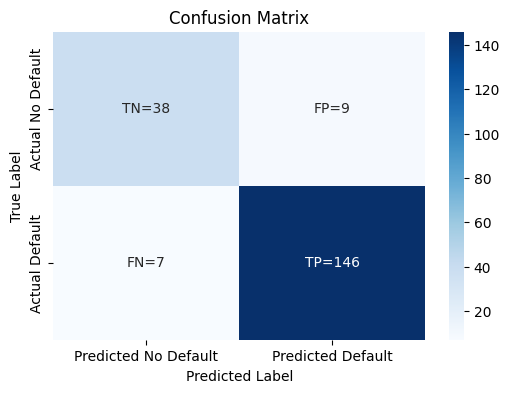

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the confusion matrix with clearer labels
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=[[f"TN={tn}", f"FP={fp}"], [f"FN={fn}", f"TP={tp}"]], fmt="", cmap='Blues', xticklabels=['Predicted No Default', 'Predicted Default'], yticklabels=['Actual No Default', 'Actual Default'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
